In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import r2_score,mean_squared_error

In [10]:
x,y=make_classification(n_samples=100,n_features=2,n_informative=1,n_redundant=0,n_classes=2,n_clusters_per_class=1
                        ,random_state=50,hypercube=False,class_sep=10)

In [11]:
m1=LogisticRegression(penalty=None,solver='sag')
m1.fit(x,y)
coef_=-m1.coef_[0,0]/m1.coef_[0,1]
intercept_=-m1.intercept_/m1.coef_[0,1]

c:\Users\viral\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


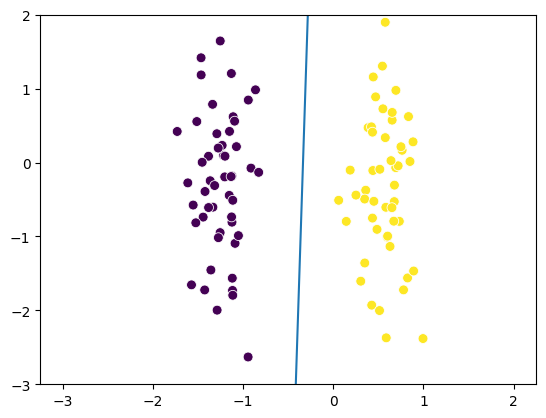

In [12]:
sns.scatterplot(x=x[:,0].flatten(),y=x[:,1].flatten(),c=y,cmap='viridis',s=50)
sns.lineplot(x=np.linspace(-3,2,100).flatten(),y=(coef_*np.linspace(-3,2,100)+intercept_).flatten())
plt.ylim(-3,2)
plt.show()

In [13]:
class my_LogisticRegression:
    def __init__(self):
        self.lr=0.1
        self.epochs=1000
    def fit(self,x,y):
        x_temp=np.insert(x,0,1,axis=1)
        w=np.ones(x_temp.shape[1])
        for i in range(self.epochs):
            y_hat=sigmoid(np.dot(x_temp,w))
            w=w+self.lr*np.dot((y-y_hat),x_temp)
        self.coef_=-w[1]/w[2]
        self.intercept_=-w[0]/w[2]

In [14]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

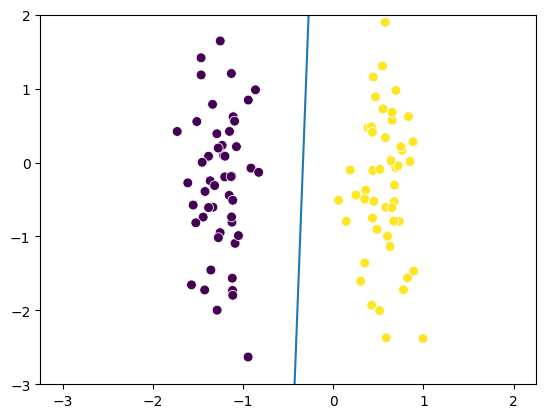

In [15]:
m2=my_LogisticRegression()
m2.fit(x,y)
sns.scatterplot(x=x[:,0].flatten(),y=x[:,1].flatten(),c=y,cmap='viridis',s=50)
sns.lineplot(x=np.linspace(-3,2,100).flatten(),y=(m2.coef_*np.linspace(-3,2,100)+m2.intercept_).flatten())
plt.ylim(-3,2)
plt.show()

In [18]:
m3=LogisticRegression()
m3.fit(x,y)
r2_score(y,m3.predict(x))
mean_squared_error(y,m3.predict(x))

np.float64(0.0)